In [12]:
class ButterflyDataset(data.Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.img_labels = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

        self.classes = sorted(self.img_labels['label'].unique())
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_name = self.img_labels.iloc[idx]['filename']
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        label_name = self.img_labels.iloc[idx]['label']
        label_idx = self.class_to_idx[label_name]
        label = torch.tensor(label_idx, dtype=torch.long)

        if self.transform:
            image = self.transform(image)

        return image, label

In [14]:
import kagglehub
import os
import pandas as pd
import torch.utils.data as data
import torchvision.transforms as transforms

BATCH_SIZE = 32
IMAGE_SIZE = 64
path = kagglehub.competition_download('aca-butterflies')

img_dir = os.path.join(path, 'competition', 'train')
df = pd.read_csv(os.path.join(path, 'competition', 'train.csv'))

data_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

dataset = ButterflyDataset(df=df, img_dir=img_dir, transform=data_transform)

dataloader = data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# 1. Collection 


In [16]:
import os

print("path =", path)
print("exists:", os.path.exists(path))
print("contents of path:")
print(os.listdir(path))

path = /Users/ritapduarte/.cache/kagglehub/competitions/aca-butterflies
exists: True
contents of path:
['.DS_Store', 'competition', 'data']


In [17]:
competition_dir = os.path.join(path, "competition")
print("competition exists:", os.path.exists(competition_dir))
print(os.listdir(competition_dir))

competition exists: True
['.DS_Store', 'test', 'train', 'train.csv']


In [18]:
train_dir = os.path.join(path, "competition", "train")
test_dir = os.path.join(path, "competition", "test")
train_csv = os.path.join(path, "competition", "train.csv")

print("train_dir exists:", os.path.exists(train_dir))
print("test_dir exists:", os.path.exists(test_dir))
print("train_csv exists:", os.path.exists(train_csv))

train_dir exists: True
test_dir exists: True
train_csv exists: True


# 2. Cleaning + 3. Quality Assessment

Esta secção tem como objetivo garantir que:
- Cada linha do CSV tem imagem correspondente
- Não há ficheiros em falta
- Não há duplicados problemáticos
- O dataset está consistente antes do split

### Verificação se os ficheiros existem, estrutura do csv e verificação de duplicados 

In [32]:
df = pd.read_csv(train_csv)
df.head()

#verificar se os ficheiros existem mesmo 
df["filepath"] = df["filename"].apply(lambda x: os.path.join(train_dir, x))
df["exists"] = df["filepath"].apply(os.path.exists)

print("Imagens existentes:", df["exists"].sum())
print("Imagens em falta:", (~df["exists"]).sum())

#verificar estrutura do csv
print("Shape:", df.shape)
print("\nColunas:", df.columns.tolist())

print("\nNúmero de classes:", df["label"].nunique())
print("Número de imagens (linhas):", len(df))
print("Filenames únicos:", df["filename"].nunique())


#verificar duplicados 
dup = df["filename"].duplicated().sum()
print("Filenames duplicados:", dup)

Imagens existentes: 5199
Imagens em falta: 0
Shape: (5199, 4)

Colunas: ['filename', 'label', 'filepath', 'exists']

Número de classes: 75
Número de imagens (linhas): 5199
Filenames únicos: 5199
Filenames duplicados: 0


Conclusão: Dataset consistente.

### Distribuição de classes

count     75.00000
mean      69.32000
std        7.38362
min       57.00000
25%       65.00000
50%       69.00000
75%       74.00000
max      105.00000
Name: count, dtype: float64


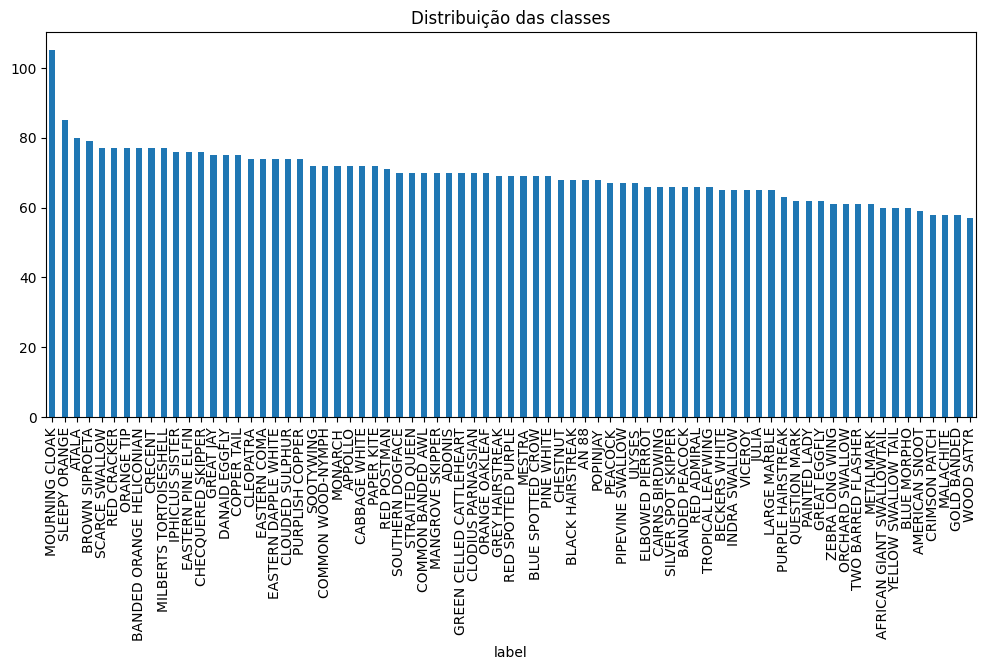

In [22]:
import matplotlib.pyplot as plt

class_counts = df["label"].value_counts()

print(class_counts.describe())

plt.figure(figsize=(12,5))
class_counts.plot(kind="bar")
plt.title("Distribuição das classes")
plt.show()

Conclusão: Dataset apenas ligeiramente desbalanceado

### Sanity check

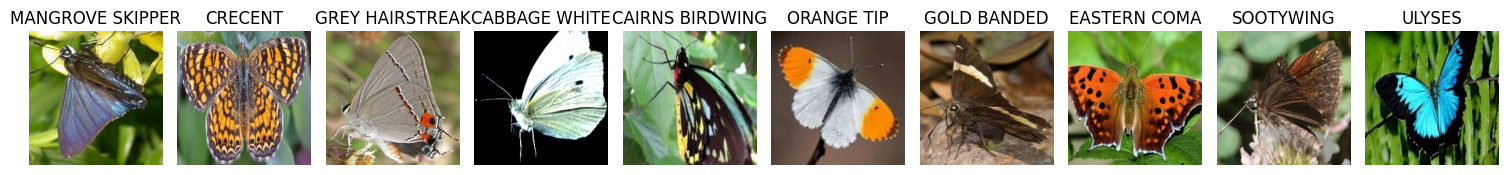

In [28]:
from PIL import Image
import matplotlib.pyplot as plt
import os

sample = df.sample(10, random_state=42)

plt.figure(figsize=(15, 5))

for i, row in enumerate(sample.itertuples(index=False)):
    img_path = os.path.join(train_dir, row.filename)
    img = Image.open(img_path).convert("RGB")
    
    plt.subplot(1, 10, i+1)
    plt.imshow(img)
    plt.title(row.label)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Image dimension

In [30]:
from PIL import Image
import numpy as np
import os

sizes = []

sample_files = df["filename"].sample(min(100, len(df)), random_state=42)

for filename in sample_files:
    img_path = os.path.join(train_dir, filename)
    img = Image.open(img_path).convert("RGB")
    sizes.append(img.size)   # (width, height)

print(sizes[:5])

[(224, 224), (224, 224), (224, 224), (224, 224), (224, 224)]


In [31]:
widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

print("Width mean:", np.mean(widths))
print("Height mean:", np.mean(heights))
print("Width min:", np.min(widths))
print("Width max:", np.max(widths))
print("Height min:", np.min(heights))
print("Height max:", np.max(heights))

Width mean: 224.0
Height mean: 224.0
Width min: 224
Width max: 224
Height min: 224
Height max: 224


Conclusão: todas as imagens tem o mesmo tamanho 

## FINAL CONCLUSIONS
The dataset was verified for consistency, with no missing or duplicated images.
The class distribution is relatively balanced across the 75 classes.
All images are already standardized to 224×224 resolution, simplifying preprocessing and making the dataset directly compatible with deep learning architectures such as CNNs and ResNet (no need to use resize).

# 4. Splitting

In [33]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))

print("\nTrain class distribution:")
print(train_df["label"].value_counts().describe())

print("\nValidation class distribution:")
print(val_df["label"].value_counts().describe())

Train size: 4159
Validation size: 1040

Train class distribution:
count    75.000000
mean     55.453333
std       5.873195
min      46.000000
25%      52.000000
50%      55.000000
75%      59.000000
max      84.000000
Name: count, dtype: float64

Validation class distribution:
count    75.000000
mean     13.866667
std       1.545117
min      11.000000
25%      13.000000
50%      14.000000
75%      15.000000
max      21.000000
Name: count, dtype: float64


# 5. Labeling

# 6.Augmentation + 7. Formatting

# 8. Integration